<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day08-discussion-2.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 8, Segment 2 discussion — a real dying ReLU

The book page *mentions* "dying ReLU" (a unit permanently stuck outputting
zero, with zero gradient, once its weights land it in negative territory for
every training example) and points to Leaky ReLU as a fix, but doesn't build
either one concretely. This notebook does both: constructs a genuinely dead
ReLU unit on real protein data, and shows Leaky ReLU staying alive on the
exact same inputs.

In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

np.random.seed(0)

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
SEQ_LEN = 150

def one_hot_encode(sequence, length=SEQ_LEN):
    encoded = np.zeros((length, len(AMINO_ACIDS)), dtype=np.float32)
    for position, residue in enumerate(sequence[:length]):
        if residue in AA_TO_INDEX:
            encoded[position, AA_TO_INDEX[residue]] = 1.0
    return encoded.flatten()

def fetch_uniprot(sl_code, size=60):
    query = f"organism_id:9606 AND reviewed:true AND cc_scl_term:{sl_code} AND length:[50 TO 500]"
    r = requests.get(
        "https://rest.uniprot.org/uniprotkb/search",
        params={"query": query, "fields": "accession,sequence", "format": "tsv", "size": size},
        timeout=60,
    )
    r.raise_for_status()
    lines = r.text.strip().split("\n")[1:]
    return [line.split("\t")[1] for line in lines if len(line.split("\t")) >= 2 and line.split("\t")[1]]

print("Fetching a small set of real cytoplasm sequences from UniProt...")
seqs = fetch_uniprot("SL-0086", size=60)
print(f"got {len(seqs)} sequences")
X = np.stack([one_hot_encode(s) for s in seqs])
print("X shape:", X.shape)

Fetching a small set of real cytoplasm sequences from UniProt...


got 60 sequences
X shape: (60, 3000)


## Building one dead ReLU unit, on purpose

A single hidden unit computes $z = w \cdot x + b$ then $\text{ReLU}(z) = \max(0,
z)$. If $w$ and $b$ are chosen so that $z < 0$ for *every* real input in `X`,
the unit outputs exactly 0 for all of them, and ReLU's derivative there is
exactly 0 too — no gradient signal will ever reach $w$ or $b$ through this
unit again, no matter what the rest of the network does.

We don't need to train anything to see this: pick weights that are large and
negative on average (`w = -3` for every one-hot feature that's actually a 1),
and a very negative bias, and check every single example.

In [2]:
def relu(z):
    return np.maximum(0.0, z)

def relu_grad(z):
    return (z > 0).astype(np.float32)

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_grad(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)

rng = np.random.RandomState(0)
w_dead = rng.uniform(-1.2, -0.8, size=X.shape[1]).astype(np.float32)  # all negative
b_dead = -5.0  # a strongly negative bias on top

z = X @ w_dead + b_dead
print("pre-activation z: min =", z.min(), " max =", z.max())
print("all z < 0?", bool((z < 0).all()))

relu_out = relu(z)
relu_g = relu_grad(z)
print()
print("ReLU output -- min/max:", relu_out.min(), relu_out.max(), "(all exactly zero?", bool((relu_out == 0).all()), ")")
print("ReLU gradient at every one of these", len(z), "real examples:",
      "all exactly zero?", bool((relu_g == 0).all()))

pre-activation z: min = -158.13965  max = -91.331795
all z < 0? True

ReLU output -- min/max: 0.0 0.0 (all exactly zero? True )
ReLU gradient at every one of these 60 real examples: all exactly zero? True


**This is a genuinely dead unit** — for every one of these real protein
inputs, both its output and its gradient are exactly zero. In a real network
during training, this unit would never update again: `dL/dw` for this unit
is `dL/d(relu_out) * relu_grad(z) * x`, and the middle term is 0 everywhere.

## The same weights, through Leaky ReLU instead

In [3]:
leaky_out = leaky_relu(z)
leaky_g = leaky_relu_grad(z)
print("Leaky ReLU output -- min/max:", leaky_out.min(), leaky_out.max())
print("Leaky ReLU gradient at these same examples -- min/max:", leaky_g.min(), leaky_g.max())
print("all gradients exactly zero?", bool((leaky_g == 0).all()), " (should be False)")
print()
print("Same dead-looking weights, but every gradient is now", leaky_g[0], "instead of 0 --")
print("small, but nonzero: this unit COULD still recover during training.")

Leaky ReLU output -- min/max: -1.5813965 -0.9133179
Leaky ReLU gradient at these same examples -- min/max: 0.01 0.01
all gradients exactly zero? False  (should be False)

Same dead-looking weights, but every gradient is now 0.01 instead of 0 --
small, but nonzero: this unit COULD still recover during training.


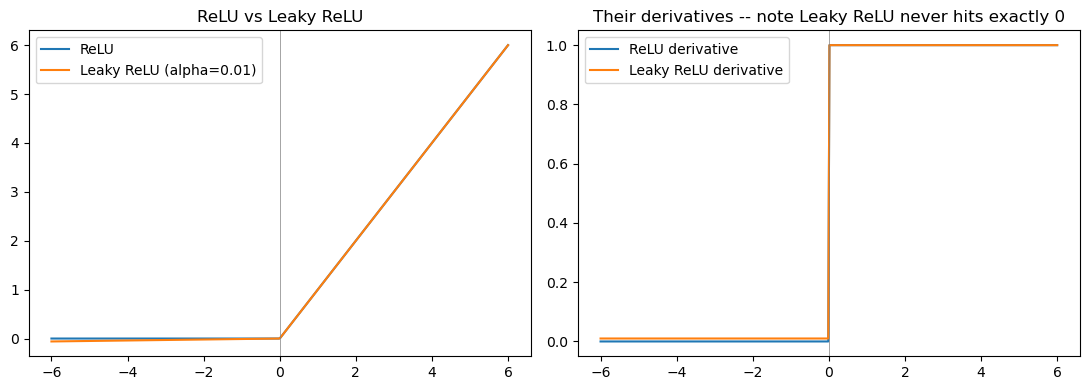

In [4]:
zz = np.linspace(-6, 6, 400)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(zz, relu(zz), label="ReLU")
axes[0].plot(zz, leaky_relu(zz), label="Leaky ReLU (alpha=0.01)")
axes[0].axvline(0, color="gray", linewidth=0.5)
axes[0].set_title("ReLU vs Leaky ReLU")
axes[0].legend()

axes[1].plot(zz, relu_grad(zz), label="ReLU derivative")
axes[1].plot(zz, leaky_relu_grad(zz), label="Leaky ReLU derivative")
axes[1].axvline(0, color="gray", linewidth=0.5)
axes[1].set_title("Their derivatives -- note Leaky ReLU never hits exactly 0")
axes[1].legend()
plt.tight_layout()
plt.show()

**Discuss:** the dead unit above was dead *by construction* (we chose the
weights). In a real trained network, could ordinary gradient descent ever
walk a unit's weights into this same all-negative-forever region on its own?
What would make that more or less likely (learning rate, weight
initialization, how many units the layer has)?